**AGENDA**

1. Cargar los datos: Adquisición de datos
2. Preparación de datos: Limpieza/preprocesamiento
3.


1. Cargar los datos

In [2]:
with open("/content/drive/MyDrive/Cuento rana.txt", "r", encoding="utf-8") as archivo:
    discurso = archivo.read()

print(discurso[:500])


En aquellos remotos tiempos, en que bastaba desear una cosa para tenerla, vivía un rey que tenía unas hijas lindísimas, especialmente la menor, la cual era tan hermosa que hasta el sol, que tantas cosas había visto, se maravillaba cada vez que sus rayos se posaban en el rostro de la muchacha. Junto al palacio real extendíase un bosque grande y oscuro, y en él, bajo un viejo tilo, fluía un manantial. En las horas de más calor, la princesita solía ir al bosque y sentarse a la orilla de la fuente. 


In [3]:
#calcular tamaño
len(discurso)

7128

Preparación de datos: Primera limpieza

In [4]:
discurso=discurso.lower()
discurso=discurso.replace(",","")
discurso=discurso.replace(";","")
discurso=discurso.replace(".","")
discurso=discurso.replace(":","")
discurso=discurso.replace('“',"")
len(discurso)

6920

In [5]:
#convertir en palabras
palabras=discurso.split()
palabras[:20]

['en',
 'aquellos',
 'remotos',
 'tiempos',
 'en',
 'que',
 'bastaba',
 'desear',
 'una',
 'cosa',
 'para',
 'tenerla',
 'vivía',
 'un',
 'rey',
 'que',
 'tenía',
 'unas',
 'hijas',
 'lindísimas']

Construcción del data set

In [6]:
import pandas as pd
import numpy as np

palabras_array=np.array(palabras)
len(palabras_array)

1315

In [9]:
#análisis de longitud de palabras
longitudes=np.array([len(palabra) for palabra in palabras_array])
print("Promedio: ",np.mean(longitudes))
print("Mediana: ",np.median(longitudes))
print("Minimo: ",np.min(longitudes))
print("Maximo", np.max(longitudes))

Promedio:  4.263117870722433
Mediana:  4.0
Minimo:  1
Maximo 13


In [10]:
#Generar un dataframe
df=pd.DataFrame(
    {
        "palabra":palabras,
        "longitud":longitudes
    }
)
#fun que me da los primeros 5 resultados
df.head()

,palabra,longitud
0,en,2
1,aquellos,8
2,remotos,7
3,tiempos,7
4,en,2


In [11]:
df["longitud"]=df["palabra"].str.len()
df.head(10)

,palabra,longitud
0,en,2
1,aquellos,8
2,remotos,7
3,tiempos,7
4,en,2
5,que,3
6,bastaba,7
7,desear,6
8,una,3
9,cosa,4


In [12]:
#frecuencia de palabras
#value_counts cuenta cuantas veces aparece el dato en el df
frecuencias=df["palabra"].value_counts()
print(frecuencias.head(20))

palabra
la      81
y       54
de      46
a       43
que     41
en      33
el      26
se      23
al      19
rana    17
su      17
con     13
tu      13
me      12
le      11
una     11
un      11
pero    10
lo       9
niña     9
Name: count, dtype: int64


In [13]:
#creo un arreglo de palabras a eliminar(stopwords)
stopwords = [
    "el","que","en","de","del","y","la","a","los","lo","al","“","un","te","es","se","no","si","le","su",'"',"por","o","son","eso","con","para","una","más","soy","así","las"
    ,"este","él","¿","?","esa"
]

In [14]:
#Filtrado
df_limpio=df[~df["palabra"].isin(stopwords)]
frecuencias=df_limpio["palabra"].value_counts()
frecuencias.head(20)

,count
palabra,
rana,17
tu,13
me,12
pero,10
oro,9
niña,9
rey,9
pelota,7
dijo,7


In [25]:
from google.colab import files

uploaded = files.upload()

Saving Rana.jpg to Rana.jpg


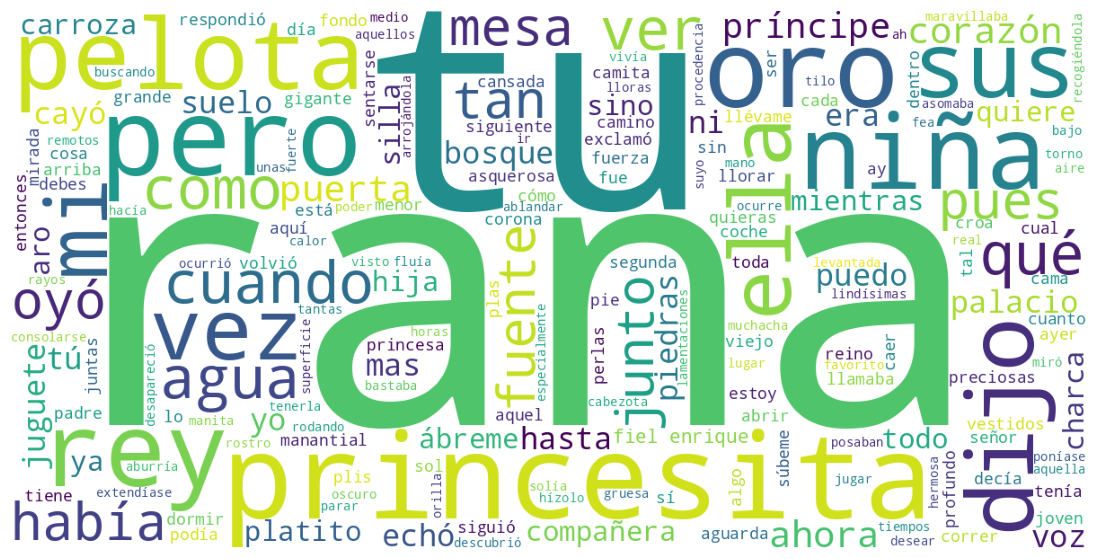

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

texto_limpio = " ".join(df_limpio["palabra"])


mascara = np.array(Image.open("Rana.jpg"))

nube=WordCloud(
  width=1200,
  height=600,
  background_color="white"
).generate(texto_limpio)

plt.figure(figsize=(15,7))
plt.imshow(nube)
plt.axis("off")
plt.show()